# Experiment: Robustness to Noises and Arbitrariness

In [1]:
import sys
import os
project_root = "" # set the root path
sys.path.insert(0, project_root)
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from functions.data import dataloader
import json
import torch
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
from functions.helper import batch_wise_random_drop, obs_field_reconstruction, sampler_test_data_generator, sampler_checkpoint_load, sampler_training_visualizer
device = [i for i in range(torch.cuda.device_count())][0]

In [2]:
secnario = "SHM"

In [3]:
stage = 2
obs_sample = [12,16,32,64]
mode = "closest"
noise_level = np.arange(0, 0.51, 0.02).tolist()
sample_times = 20
position = 7
path = os.listdir("../output/")[next((i for i, p in enumerate(os.listdir("../output/")) if secnario in str(p)), None)]
path = f"../output/{path}"

In [4]:
def add_noise_to_obs(obs, noise_level):

    obs_noisy = obs.clone()
    B, N, T = obs_noisy.shape

    values = obs_noisy[..., 2:]   # [B, N, 21]

    std = values.reshape(B, -1).std(dim=1, keepdim=True).clamp(min=1e-8)  # [B,1]
    std = std.view(B, 1, 1)  # broadcast to [B,1,1]

    noise = noise_level * std * torch.randn_like(values)

    obs_noisy[..., 2:] = values + noise
    return obs_noisy

12: start...
-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_12.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 12, 7])


100%|██████████| 26/26 [00:35<00:00,  1.37s/it]


16: start...
-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_16.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 16, 7])


100%|██████████| 26/26 [00:35<00:00,  1.36s/it]


32: start...
-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_32.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 32, 7])


100%|██████████| 26/26 [00:35<00:00,  1.36s/it]


64: start...
-> Field Inversion Checkpoint loaded: output/SHM-2025-12-28-04-58-41/checkpoints/stage_2_64.pt
-> Dataloader: target shape = torch.Size([1, 1, 64, 64]) | observation shape = torch.Size([1, 4096, 7]) | dropped_observation shape = torch.Size([1, 64, 7])


100%|██████████| 26/26 [00:35<00:00,  1.36s/it]


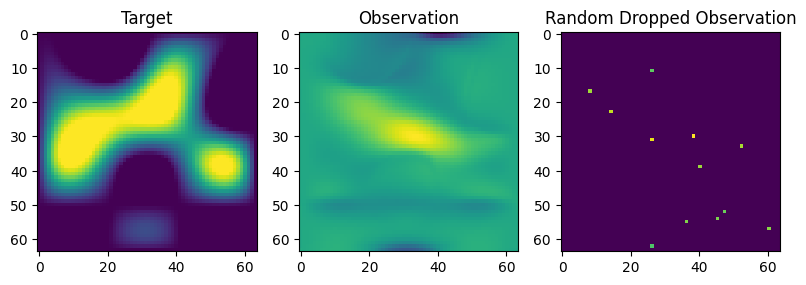

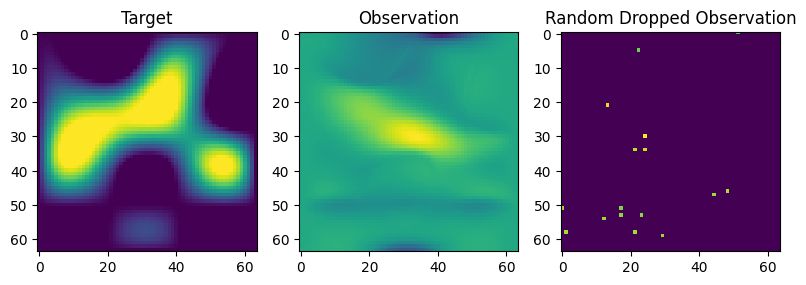

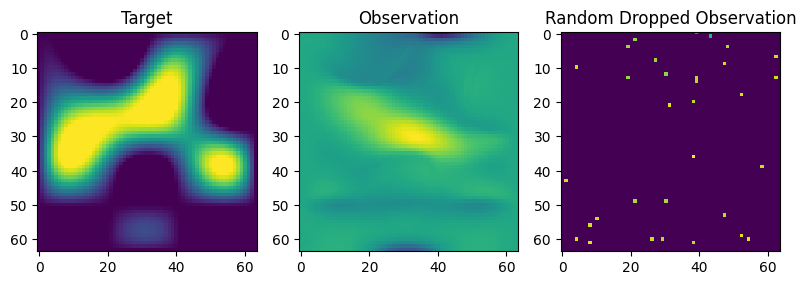

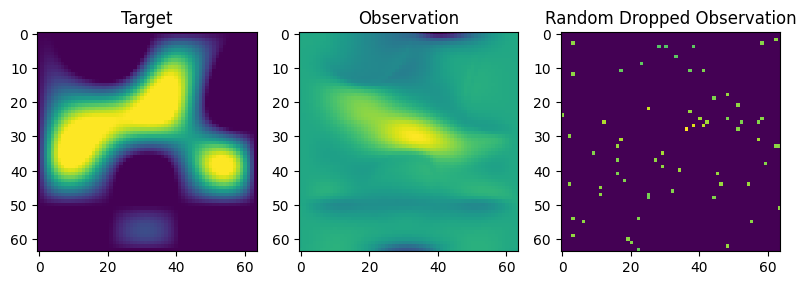

In [5]:
gen_result = {}

for obs in obs_sample:
    print(f"{obs}: start...")
    model, certainty_param = sampler_checkpoint_load(path, stage, obs, mode, device)
    target, _, drop_obs,_,_,_ = sampler_test_data_generator(path, stage, obs, mode, device, shuffle=False, position=7)
    drop_obs_batch = drop_obs.repeat(sample_times, 1, 1)
    
    for noise in tqdm(noise_level):
        # create noises
        drop_obs_noisy = add_noise_to_obs(drop_obs_batch, noise)
        img = model.sample(shape=(sample_times,1,64,64), steps=80, device="cuda", conditions=drop_obs_batch)
        gen_result[f"{obs}-{noise}"] = img.squeeze(1)

In [6]:
with h5py.File(f"Outputs/PIS_NoiseArb_{secnario}.h5", "w") as f:
    for key_val in gen_result.keys():
        f.create_dataset(str(key_val), data = gen_result[key_val].detach().cpu().numpy())